In [1]:
import numpy as np
import scipy as sc
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
#fundamental constants
k_B = 1.38*10**(-23)
h = 6.626*10**(-34)
c = 3*10**(8)

See table 1

In [3]:
#fiducial parameters for CMB radiation
T_CMB = 2.725
y_param =1.77*10**(-6)
mu = 2*10**(-8)

dmu = -mu
dT = 10**(-3)
dy = y_param

#instrumental parameters
etendue = 200*10**(-4)
N_horns = 10

#simulation parameters
precision_arr = np.logspace(-9,-3.5,100,base=10)
N_bins = 1490
freq_start= 10
freq_stop = 1500
freq_space = np.linspace(freq_start,freq_stop,N_bins)*10**(9)
freq_range = freq_space

See table 2

In [4]:
#fiducial parameters for foregrounds

#thermal_dust
A_d = 1.36*10**(-20)
B_d = 1.53
T_d = 21
d_A_d = A_d/100
d_B_d = B_d/100
d_T_d = T_d/100

#synchrotron
A_s = 2.88*10**(-24)
d_A_s = A_s/100
ref_freq_s = 100*10**(9)
beta_s= -0.82
d_beta_s = beta_s/100
w2s = 0.2
d_w2s = w2s/100

#cib
A_cib = 3.46*10**(-21)
B_cib = 0.86
T_cib = 18.8
d_A_cib = A_cib/100
d_B_cib = B_cib/100
d_T_cib = T_cib/100

#free_free

Te = 7000
Teff = (Te / 10**(3)) ** 1.5
ref_ff = 255.33*10**9 * Teff
beta_ff = (np.sqrt(3) / np.pi)
d_beta_ff =beta_ff/100
A_ff = 300*10**(-26)
d_A_ff = A_ff/100


In [5]:
#Path space for FTS
x_max = 2.5*10**(-11)
dx = 7.5*10**(-14)
path_space = np.arange(0,x_max,dx)
num_meas = len(path_space)

In [6]:
def num_photons_var_to_intensity_var(n_var,f,etendue,bandwidth):
    return n_var*(h*f/(etendue*bandwidth))**2

In [7]:
def param_derivatives(n_params,params,d_params,k,freq,foregrounds):
    shift = np.zeros(n_params)
    shift[k] = d_params[k]
    if(foregrounds==True):
        CMB_0 = calc_full_spectrum(params,freq)
        CMB_shifted = calc_full_spectrum(params+shift,freq)
    else:
        CMB_0 = calc_cmb_spectrum(params,freq)
        CMB_shifted = calc_cmb_spectrum(params+shift,freq)
    return (CMB_shifted-CMB_0)/d_params[k]

In [8]:
def calc_full_spectrum(params,f):
        mu, T_CMB,y_param,A_d,B_d, T_d,A_s, beta_s, A_ff, A_cib,B_cib,T_cib,w2s  = params 
        x = h*f/(k_B*T_CMB)
        expx = np.exp(x)
    
        CMB = (2*h*f**(3))*(1/(np.exp((h*f*(1-0.456*mu)/(k_B*T_CMB)+mu))-1))/(c*c)
        n_y = y_param*(x*expx)/((expx-1)**2)*(x*(expx+1)/(expx-1)-4)
        y_distort = 2*h*f**(3)/(c**2)*n_y

        x_dust= h*f/(k_B*T_d)
        thermal_dust= A_d*x_dust**B_d*x_dust**3/(np.exp(x_dust) - 1.0)
            
        synchrotron_emission = A_s*(f/ref_freq_s)**(beta_s)*(1. + 0.5 * w2s * np.log(f / ref_freq_s) ** 2) 
        free_free_emission = A_ff*(1.+ np.log(1. + (ref_ff / f) ** beta_ff)) 

        x_cib = h*f/(k_B*T_cib)
        cib = A_cib*x_cib**B_cib*x_cib**3/(np.exp(x_cib)-1)

        full_spectrum = CMB + y_distort + thermal_dust+synchrotron_emission+free_free_emission+cib
    
        return full_spectrum

In [9]:
def calc_cmb_spectrum(params,f):
        x = h*f/(k_B*params[1])
        expx = np.exp(x)
        CMB = (2*h*f**(3))*(1/(np.exp((h*f*(1-0.456*params[0])/(k_B*params[1])+params[0]))-1))/(c*c)
        n = params[2]*(x*expx)/((expx-1)**2)*(x*(expx+1)/(expx-1)-4)
        y_distort = 2*h*f**(3)/(c**2)*n
        full_spectrum = CMB + y_distort 
        return full_spectrum

In [10]:
def num_photon_sig(freq,params,signal_index,foregrounds,freq_index):  

    mu,T_CMB,y_param = params[0],params[1],params[2]
    x = h*freq/(k_B*T_CMB)
    expx = np.exp(x)
    cmb = (2*h*freq**(3))*(1/(np.exp((h*freq/(k_B*T_CMB)*(1-0.456*mu)+mu))-1))/(c*c)
    n = y_param*(x*expx)/((expx-1)**2)*(x*(expx+1)/(expx-1)-4)
    y_distort = 2*h*freq**(3)/(c**2)*n 
    if(foregrounds==True):
        mu, T_CMB,y_param,A_d,B_d, T_d,A_s, beta_s, A_ff, A_cib,B_cib,T_cib,w2s  = params 
        x_dust = h*freq/(k_B*T_d)
        thermal_dust= A_d*x_dust**B_d*x_dust**3/(np.exp(x_dust) - 1.0)  
        synchrotron_emission = A_s*(freq/ref_freq_s)**(beta_s)*(1. + 0.5 * w2s* np.log(freq / ref_freq_s) ** 2)  
        free_free_emission = A_ff*(1.+ np.log(1. + (ref_ff / freq) ** beta_ff))   
        x_cib = h*freq/(k_B*T_cib)
        cib = (A_cib*x_cib**B_cib*x_cib**3)/(np.exp(x_cib)-1)
    if(freq_index==0):
        bandwidth = freq_range[1]-freq_range[0]
    else:
        bandwidth = freq_range[freq_index]-freq_range[freq_index-1]
    convert_intensity_to_photon_num = 1/(h*freq)*etendue*bandwidth
    if(foregrounds==False and signal_index>1):
        print('Error flagged')
        return 0
    if(signal_index==0):
        return (cmb+y_distort)*convert_intensity_to_photon_num
    elif(signal_index==1):
        return thermal_dust*convert_intensity_to_photon_num
    elif(signal_index==2):
        return synchrotron_emission*convert_intensity_to_photon_num
    elif(signal_index==3):
        return free_free_emission*convert_intensity_to_photon_num
    elif(signal_index==4):
        return cib*convert_intensity_to_photon_num

In [11]:
def fisher_optimal_fg(freq_range,n_bins,n_params,mu,params,d_params,n_signals,foregrounds):
    derivative_mat = np.zeros((n_params,N_bins))
    fisher_mat = np.zeros((n_params,n_params))
    bandwidth = 0
    freq_index = 0    
    for freq in freq_range:
        if(freq_index==0):
            bandwidth = freq_range[1]-freq_range[0]
        else:
            bandwidth = freq_range[freq_index]-freq_range[freq_index-1]
        mode= 2*etendue*freq**2/(c**2)*bandwidth
        for k in range(n_params):
            derivative_mat[k][freq_index] = param_derivatives(n_params,params,d_params,k,freq,foregrounds)       
        sig_I_sq=0
        n_phot = 0
        for signal_index in range(n_signals):
            n_phot += num_photon_sig(freq,params,signal_index,foregrounds,freq_index)
        n_var = n_phot+n_phot**2/mode
        sig_I_sq= num_photons_var_to_intensity_var(n_var,freq,etendue,bandwidth)     
        
            
        for j in range (0,n_params):
            for k in range (0,j+1):
                fisher_mat[j][k] += derivative_mat[j][freq_index]*derivative_mat[k][freq_index]/sig_I_sq
                fisher_mat[k][j] = fisher_mat[j][k]
        freq_index = freq_index+1
    return fisher_mat

In [12]:
def fisher_fts(freq_range,n_bins,n_params,params,d_params,path_space,n_signals,foregrounds):

    fisher_mat = np.zeros((n_params,n_params))
    bandwidth = 0
    for x in path_space:
        sig_I_sq_left=0
        sig_I_sq_right = 0
        derivative_mat_left = np.zeros((n_params))
        derivative_mat_right = np.zeros((n_params))
        freq_index = 0
        
        for freq in freq_range:  
            
            for k in range(n_params):
                derivative_mat_left[k]+=0.5*(1+np.cos(2*np.pi*freq*x))*param_derivatives(n_params,params,d_params,k,freq,foregrounds)
                derivative_mat_right[k]+=0.5*(1-np.cos(2*np.pi*freq*x))*param_derivatives(n_params,params,d_params,k,freq,foregrounds)
            if(freq_index==0):
                bandwidth = freq_range[1]-freq_range[0]
            else:
                bandwidth = freq_range[freq_index]-freq_range[freq_index-1]
            
            mode_single_polarisation =etendue*freq**2/(c**2)*bandwidth
            n_phot_single_detector_left = 0
            n_phot_single_detector_right = 0
            for signal_index in range(n_signals):
                n_phot_single_detector_left += 0.5*(num_photon_sig(freq,params,signal_index,foregrounds,freq_index)*(1+np.cos(2*np.pi*freq*x))/2)
                n_phot_single_detector_right += 0.5*(num_photon_sig(freq,params,signal_index,foregrounds,freq_index)*(1-np.cos(2*np.pi*freq*x))/2)
            n_phot_single_detector_left+=0.5*(num_photon_sig(freq,params,0,foregrounds,freq_index)*(1-np.cos(2*np.pi*freq*x))/2)
            n_phot_single_detector_right+=0.5*(num_photon_sig(freq,params,0,foregrounds,freq_index)*(1+np.cos(2*np.pi*freq*x))/2)
            n_var_both_detectors_left = 2*(n_phot_single_detector_left+n_phot_single_detector_left**2/mode_single_polarisation)
            n_var_both_detectors_right = 2*(n_phot_single_detector_right+n_phot_single_detector_right**2/mode_single_polarisation)
            sig_I_sq_left+= num_photons_var_to_intensity_var(n_var_both_detectors_left,freq,etendue,bandwidth)
            sig_I_sq_right+= num_photons_var_to_intensity_var(n_var_both_detectors_right,freq,etendue,bandwidth)
            freq_index+=1
           
        for j in range (0,n_params):
            for k in range (0,j+1):
                fisher_mat[j][k] += derivative_mat_left[j]*derivative_mat_left[k]/sig_I_sq_left + derivative_mat_right[j]*derivative_mat_right[k]/sig_I_sq_right
                fisher_mat[k][j] = fisher_mat[j][k]
    return fisher_mat

In [13]:
n_params = 3
n_params_fg = 13
n_signals = 1
n_signals_fg = 5

param_no_fg = np.array([mu,T_CMB,y_param])
d_param_no_fg = np.array([dmu,dT,dy])

params= [mu,T_CMB,y_param,A_d,B_d, T_d,A_s, beta_s, A_ff, A_cib,B_cib,T_cib,w2s]
d_params= np.array([dmu,dT,dy,d_A_d,d_B_d,d_T_d,d_A_s,d_beta_s, d_A_ff,d_A_cib,d_B_cib,d_T_cib,d_w2s])

In [14]:
    
fisher_mat_optimal = fisher_optimal_fg(freq_space,N_bins,n_params,mu,param_no_fg,d_param_no_fg,n_signals,foregrounds=False)
fisher_inverse = np.linalg.inv(fisher_mat_optimal)

fisher_mat_optimal_fg = fisher_optimal_fg(freq_space,N_bins,n_params_fg,mu,params,d_params,n_signals_fg,foregrounds=True)
fisher_inverse_fg = np.linalg.inv(fisher_mat_optimal_fg)

#each of the 4 detectors for an FTS has 1/4 total etendue
etendue = etendue/4

fisher_mat_fts = fisher_fts(freq_space,N_bins,n_params,param_no_fg,d_param_no_fg,path_space,n_signals,foregrounds=False)
fisher_inverse_fts = np.linalg.inv(fisher_mat_fts)
    
fisher_mat_fts_fg = fisher_fts(freq_space,N_bins,n_params_fg,params,d_params,path_space,n_signals_fg,foregrounds=True)
fisher_inverse_fts_fg = np.linalg.inv(fisher_mat_fts_fg)
    


In [15]:
optimal = np.zeros_like(precision_arr)
optimal_fg = np.zeros_like(precision_arr)
fts = np.zeros_like(precision_arr)
fts_fg = np.zeros_like(precision_arr)

j = 0
for sigma_mu in precision_arr:

    optimal[j] = (fisher_inverse[0][0])/(sigma_mu**2)    
    optimal_fg[j]= (fisher_inverse_fg[0][0])/(sigma_mu**2)

    fts[j] = (fisher_inverse_fts[0][0])/(sigma_mu**2)*num_meas
    fts_fg[j]= (fisher_inverse_fts_fg[0][0])/(sigma_mu**2)*num_meas
    
    j+=1

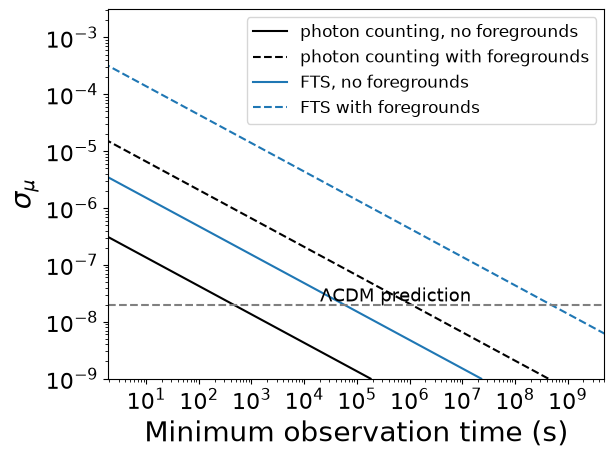

In [16]:

plt.plot(N_horns*optimal,precision_arr, linestyle = '-',color='black',label = 'photon counting, no foregrounds')
plt.plot(N_horns*optimal_fg,precision_arr,linestyle='--',color='black', label='photon counting with foregrounds')
plt.plot(fts,precision_arr, linestyle = '-',color='tab:blue',label = 'FTS, no foregrounds')
plt.plot(fts_fg,precision_arr,linestyle='--',color='tab:blue', label='FTS with foregrounds')

plt.ylabel('$\sigma_\mu$',fontsize=20)
plt.xlabel('Minimum observation time (s)',fontsize = 20)
plt.xscale('log')
plt.yscale('log')
plt.axhline(y=2*10**(-8), color='gray', linestyle='--' )
plt.text(x=2*10**4,y=2.25*10**(-8),s='$\Lambda$CDM prediction', fontsize = 13)
plt.legend(loc="upper right",fontsize=12)
plt.ylim(10**(-9),10**(-2.5))
plt.xlim(fts_fg[99],5*10**(9))
plt.yticks(fontsize = 16)
plt.xticks(fontsize = 16)

plt.savefig("Figure_1.pdf",bbox_inches ='tight')

In [17]:
#simulation parameters for SPECTER
precision_arr_specter = np.logspace(-9,-5,100,base=10)
N_bins = 1999
freq_start= 1
freq_stop = 2000
freq_space = np.linspace(freq_start,freq_stop,N_bins)*10**(9)
freq_range = freq_space
#instrumental parameters for SPECTER
etendue = 7800*10**(-4)
N_horns_specter = 20

SPECTER = [mu/5, 3.15*10**(7)]




In [18]:
    
fisher_mat_optimal_specter = fisher_optimal_fg(freq_space,N_bins,n_params,mu,param_no_fg,d_param_no_fg,n_signals,foregrounds=False)
fisher_inverse_specter = np.linalg.inv(fisher_mat_optimal_specter)

fisher_mat_optimal_fg_specter = fisher_optimal_fg(freq_space,N_bins,n_params_fg,mu,params,d_params,n_signals_fg,foregrounds=True)
fisher_inverse_fg_specter = np.linalg.inv(fisher_mat_optimal_fg_specter)

#each of the 4 detectors for an FTS has 1/4 total etendue
etendue = etendue/4

fisher_mat_fts_specter = fisher_fts(freq_space,N_bins,n_params,param_no_fg,d_param_no_fg,path_space,n_signals,foregrounds=False)
fisher_inverse_fts_specter = np.linalg.inv(fisher_mat_fts_specter)
    
fisher_mat_fts_fg_specter = fisher_fts(freq_space,N_bins,n_params_fg,params,d_params,path_space,n_signals_fg,foregrounds=True)
fisher_inverse_fts_fg_specter = np.linalg.inv(fisher_mat_fts_fg_specter)
    


In [19]:
optimal_specter = np.zeros_like(precision_arr)
optimal_fg_specter = np.zeros_like(precision_arr)
fts_specter = np.zeros_like(precision_arr)
fts_fg_specter = np.zeros_like(precision_arr)

j = 0
for sigma_mu in precision_arr_specter:

    optimal_specter[j] = (fisher_inverse_specter[0][0])/(sigma_mu**2)    
    optimal_fg_specter[j]= (fisher_inverse_fg_specter[0][0])/(sigma_mu**2)
    fts_specter[j] = (fisher_inverse_fts_specter[0][0])/(sigma_mu**2)*num_meas
    fts_fg_specter[j]= (fisher_inverse_fts_fg_specter[0][0])/(sigma_mu**2)*num_meas
    
    j+=1

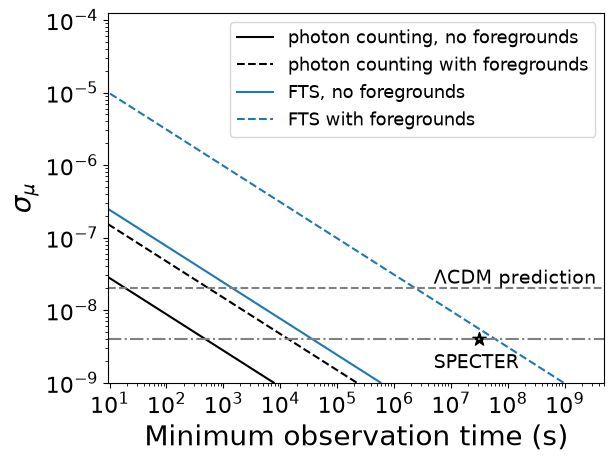

In [20]:


plt.plot(N_horns_specter*optimal_specter,precision_arr_specter, linestyle = '-',color='black',label = 'photon counting, no foregrounds')
plt.plot(N_horns_specter*optimal_fg_specter,precision_arr_specter,linestyle='--',color='black', label='photon counting with foregrounds')

plt.plot(fts_specter,precision_arr_specter,linestyle = '-',color='tab:blue',label = 'FTS, no foregrounds')
plt.plot(fts_fg_specter,precision_arr_specter,linestyle='--',color='tab:blue', label='FTS with foregrounds')
plt.ylabel('$\sigma_\mu$',fontsize=20)
plt.xlabel('Minimum observation time (s)',fontsize = 20)
plt.xscale('log')
plt.yscale('log')

plt.axhline(y=mu, color='gray', linestyle='--' )
plt.axhline(y = mu/5, color='gray', linestyle='-.')
plt.text(x=5*10**6,y=2.3*10**(-8),s='$\Lambda$CDM prediction', fontsize = 14)
plt.text(x=5*10**6,y=10**(-8.8),s='SPECTER', fontsize = 14)


plt.scatter(SPECTER[1],SPECTER[0],color='black',marker='*',s=100)


plt.legend(loc="upper right",fontsize= 13)
n_params = 3
n_params_fg = 13
n_signals = 1
n_signals_fg = 5
plt.ylim(10**(-9),1.25*10**(-4))
plt.xlim(fts_fg_specter[99],5*10**(9))

plt.yticks(fontsize = 16)
plt.xticks(fontsize = 16)

plt.savefig("SPECTER.pdf",bbox_inches='tight')


In [21]:
#simulation parameters for PIXIE
precision_arr_pixie = np.logspace(-9,-5,100,base=10)
N_bins = 300
freq_start= 28
freq_stop = 6000
freq_space = np.linspace(freq_start,freq_stop,N_bins)*10**9
freq_range = freq_space

#instrumental parameters for PIXIE 
#total etendue for 4 detectors
etendue = 16*10**(-4)
N_horns_PIXIE = 10

PIXIE_baseline = [4.6*10**(-7), 2*10**(7),]
PIXIE_extended = [2.7*10**(-7), 2.2*10**(8)]


In [22]:
fisher_mat_optimal_pixie = fisher_optimal_fg(freq_space,N_bins,n_params,mu,param_no_fg,d_param_no_fg,n_signals,foregrounds=False)
fisher_inverse_pixie = np.linalg.inv(fisher_mat_optimal_pixie)

fisher_mat_optimal_fg_pixie = fisher_optimal_fg(freq_space,N_bins,n_params_fg,mu,params,d_params,n_signals_fg,foregrounds=True)
fisher_inverse_fg_pixie = np.linalg.inv(fisher_mat_optimal_fg_pixie)

#each of the 4 detectors for an FTS has 1/4 total etendue
etendue = etendue/4

fisher_mat_fts_pixie = fisher_fts(freq_space,N_bins,n_params,param_no_fg,d_param_no_fg,path_space,n_signals,foregrounds=False)
fisher_inverse_fts_pixie = np.linalg.inv(fisher_mat_fts_pixie)
    
fisher_mat_fts_fg_pixie = fisher_fts(freq_space,N_bins,n_params_fg,params,d_params,path_space,n_signals_fg,foregrounds=True)
fisher_inverse_fts_fg_pixie = np.linalg.inv(fisher_mat_fts_fg_pixie)
    

In [23]:
optimal_pixie = np.zeros_like(precision_arr)
optimal_fg_pixie = np.zeros_like(precision_arr)
fts_pixie = np.zeros_like(precision_arr)
fts_fg_pixie = np.zeros_like(precision_arr)


j = 0
for sigma_mu in precision_arr_pixie:

    optimal_pixie[j] = (fisher_inverse_pixie[0][0])/(sigma_mu**2)
    optimal_fg_pixie[j] = (fisher_inverse_fg_pixie[0][0])/(sigma_mu**2)
    fts_pixie[j] = (fisher_inverse_fts_pixie[0][0])/(sigma_mu**2)*num_meas
    fts_fg_pixie[j] = (fisher_inverse_fts_fg_pixie[0][0])/(sigma_mu**2)*num_meas
    j+=1

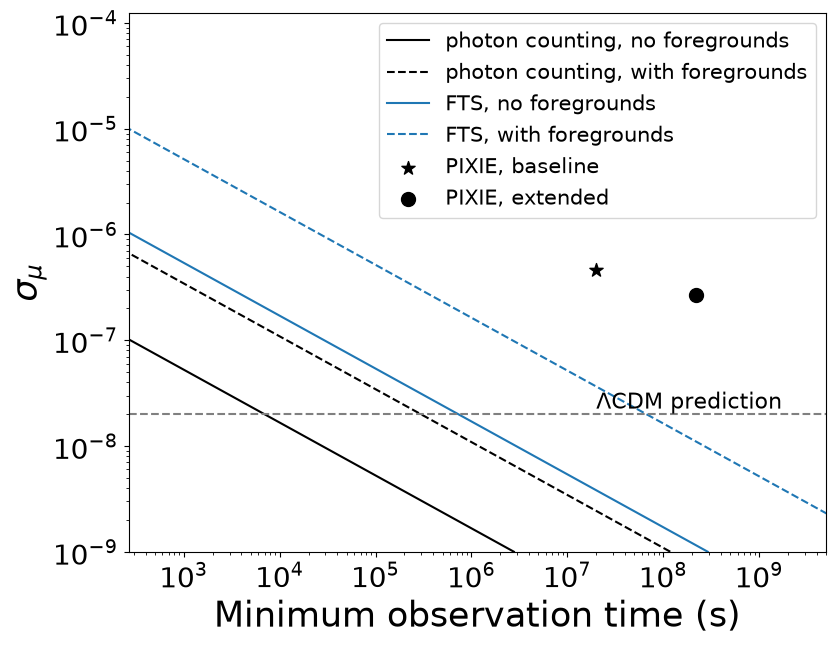

In [24]:
plt.figure(figsize=(9, 7))

plt.plot(N_horns*optimal_pixie,precision_arr_pixie, linestyle = '-',color='black',label = 'photon counting, no foregrounds')
plt.plot(N_horns*optimal_fg_pixie,precision_arr_pixie,linestyle='--',color='black', label='photon counting, with foregrounds')

plt.plot(fts_pixie,precision_arr_pixie, linestyle = '-',color='tab:blue',label = 'FTS, no foregrounds')
plt.plot(fts_fg_pixie,precision_arr_pixie,linestyle='--',color='tab:blue', label='FTS, with foregrounds')

plt.scatter(PIXIE_baseline[1],PIXIE_baseline[0],label='PIXIE, baseline',color='black',marker='*',s=100)
plt.scatter(PIXIE_extended[1],PIXIE_extended[0],label='PIXIE, extended',color='black',marker='o',s=100)

plt.ylabel('$\sigma_\mu$',fontsize=25)
plt.xlabel('Minimum observation time (s)',fontsize = 25)
plt.xscale('log')
plt.yscale('log')
plt.axhline(y=2*10**(-8), color='gray', linestyle='--' )
plt.text(x=2*10**7,y=2.25*10**(-8),s='$\Lambda$CDM prediction', fontsize = 16)
plt.legend(loc="upper right",fontsize=15)
plt.ylim(10**(-9),1.25*10**(-4))
plt.xlim(fts_fg_pixie[99],5*10**(9))
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)

plt.savefig("PIXIE.pdf",bbox_inches ='tight')

In [25]:
#CMB and foreground signals
N_bins = 1000000
freq_start= 10
freq_stop = 1500
freq_space = np.linspace(freq_start,freq_stop,N_bins)*10**(9)
freq_range = freq_space
bandwidth = freq_space[1]-freq_space[0]

CMB_sig_0 = np.zeros_like(freq_range)
CMB_sig_mu = np.zeros_like(freq_range)
thermal_dust = np.zeros_like(freq_range)
synchrotron_emission =np.zeros_like(freq_range)
free_free_emission =np.zeros_like(freq_range)
y_distort = np.zeros_like(freq_range)
mu_signal_abs=np.zeros_like(freq_range)


params_mu_0 = [0,T_CMB,y_param,A_d,B_d, T_d,A_s, beta_s, A_ff, A_cib,B_cib,T_cib,w2s]
cib = np.zeros_like(freq_range)
foregrounds = True
i = 0
for freq in freq_range:
    x = h*freq/(k_B*T_CMB)
    expx = np.exp(x)
    convert_photon_num_to_intensity = (h*freq)/(etendue*bandwidth)
    CMB_sig_mu[i] = num_photon_sig(freq,params,signal_index=0,foregrounds=True,freq_index=i)*convert_photon_num_to_intensity
    CMB_sig_0[i] = num_photon_sig(freq,params_mu_0,signal_index=0,foregrounds=True,freq_index=i)*convert_photon_num_to_intensity
    n = params[2]*(x*expx)/((expx-1)**2)*(x*(expx+1)/(expx-1)-4)
    y_distort[i] = np.abs(2*h*freq**(3)/(c**2)*n)
    mu_signal_abs[i] = np.abs(CMB_sig_mu[i] - CMB_sig_0[i])
    thermal_dust[i] = num_photon_sig(freq,params,signal_index=1,foregrounds=True,freq_index=i)*convert_photon_num_to_intensity
    synchrotron_emission[i] = num_photon_sig(freq,params,signal_index=2,foregrounds=True,freq_index=i)*convert_photon_num_to_intensity
    free_free_emission[i] = num_photon_sig(freq,params,signal_index=3,foregrounds=True,freq_index=i)*convert_photon_num_to_intensity   
    cib[i]=num_photon_sig(freq,params,signal_index=4,foregrounds=True,freq_index=i)*convert_photon_num_to_intensity   
    i = i+1


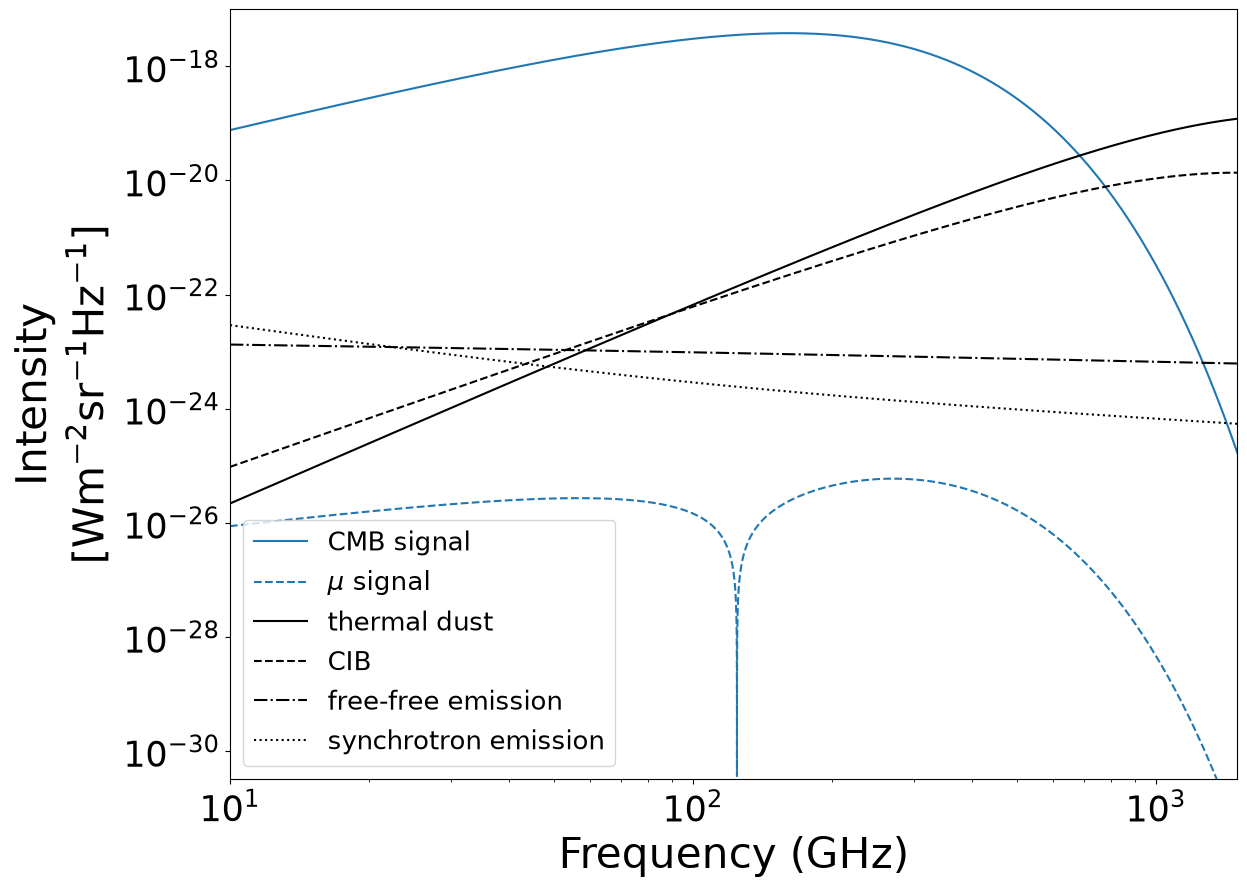

In [26]:
plt.figure(figsize=(13, 10))
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Frequency (GHz)',fontsize = 30)
plt.ylabel('Intensity\n$[\\mathrm{W m^{-2} sr^{-1} Hz^{-1}}]$',fontsize =30)
plt.plot(freq_range/10**9,CMB_sig_0, label = 'CMB signal',color='tab:blue',linestyle='-')
plt.plot(freq_range/10**9,mu_signal_abs, label = '$\mu$ signal',color='tab:blue',linestyle='--')
plt.plot(freq_range/10**9,thermal_dust,label='thermal dust', color='black',linestyle='-')
plt.plot(freq_range/10**9,cib,label='CIB', color='black',linestyle='--')
plt.plot(freq_range/10**9, free_free_emission,label='free-free emission', color='black', linestyle='-.')
plt.plot(freq_range/10**9,synchrotron_emission,label='synchrotron emission', color='black',linestyle=':')

plt.legend(fontsize = 19,loc='lower left',ncols=1)
plt.ylim([10**(-30.5),10**(-17)])
plt.xlim([freq_range[0]/10**9,freq_range[-1]/10**9])

plt.xticks(fontsize = 25)
plt.yticks(fontsize = 25)



plt.savefig("Figure_2.pdf",bbox_inches='tight')
